# Imports library

In [3]:
import torch 
import torch_geometric
from torch_geometric.utils import from_smiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import seaborn as sns
import networkx as nx
from math import sqrt
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, PandasTools, Descriptors
import torch.nn.functional as F
from torch.utils.data import random_split
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx
from torch_geometric.nn import AttentiveFP
import os
import random
from collections import Counter

import torch

from torch_geometric.data import InMemoryDataset, download_url, extract_gz
from torch_geometric.utils import from_smiles
from sklearn.metrics import r2_score, mean_squared_error

c:\Users\pc\my_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Add function seed for stable random value generation**

In [4]:

plt.style.use('ggplot')

def seed_set(seed=50):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
seed_set()

**Imports datasets and describe it**

In [5]:
df_final = pd.read_csv(r'C:\Users\pc\Downloads\GNN prediction solubility\Lipophilicity.csv')
print(df_final.head())
print(df_final.describe())
print(df_final['smiles'].nunique())

   CMPD_CHEMBLID   exp                                             smiles
0   CHEMBL596271  3.54            Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14
1  CHEMBL1951080 -1.18  COc1cc(OC)c(cc1NC(=O)CSCC(=O)O)S(=O)(=O)N2C(C)...
2     CHEMBL1771  3.69             COC(=O)[C@@H](N1CCc2sccc2C1)c3ccccc3Cl
3   CHEMBL234951  3.37  OC[C@H](O)CN1C(=O)C(Cc2ccccc12)NC(=O)c3cc4cc(C...
4   CHEMBL565079  3.10  Cc1cccc(C[C@H](NC(=O)c2cc(nn2C)C(C)(C)C)C(=O)N...
               exp
count  4200.000000
mean      2.186336
std       1.203004
min      -1.500000
25%       1.410000
50%       2.360000
75%       3.100000
max       4.500000
4200


**Visualise the distribution of my target**

Text(0, 0.5, 'Count')

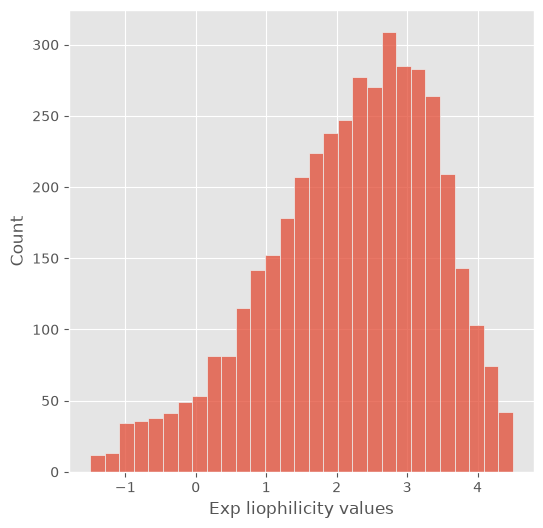

In [6]:

plt.figure(figsize= (6 , 6 ))
sns.histplot(data= df_final , x = df_final['exp'] , y  = None , hue = None  )
plt.xlabel('Exp liophilicity values')
plt.ylabel('Count')


          
             

In [7]:
PandasTools.AddMoleculeColumnToFrame(df_final, smilesCol='smiles', molCol='mol')
print(df_final.head())



   CMPD_CHEMBLID   exp                                             smiles  \
0   CHEMBL596271  3.54            Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14   
1  CHEMBL1951080 -1.18  COc1cc(OC)c(cc1NC(=O)CSCC(=O)O)S(=O)(=O)N2C(C)...   
2     CHEMBL1771  3.69             COC(=O)[C@@H](N1CCc2sccc2C1)c3ccccc3Cl   
3   CHEMBL234951  3.37  OC[C@H](O)CN1C(=O)C(Cc2ccccc12)NC(=O)c3cc4cc(C...   
4   CHEMBL565079  3.10  Cc1cccc(C[C@H](NC(=O)c2cc(nn2C)C(C)(C)C)C(=O)N...   

                                                 mol  
0  <rdkit.Chem.rdchem.Mol object at 0x0000015D008...  
1  <rdkit.Chem.rdchem.Mol object at 0x0000015D009...  
2  <rdkit.Chem.rdchem.Mol object at 0x0000015D009...  
3  <rdkit.Chem.rdchem.Mol object at 0x0000015D009...  
4  <rdkit.Chem.rdchem.Mol object at 0x0000015D009...  


**Add a molecular weight descriptors to my data**

In [8]:
mol_wht = []
for mol in df_final['mol']  : 
    mol = Descriptors.MolWt(mol)
    mol_wht.append(mol)
df_final['Molwht']  = mol_wht
print(df_final.head())



   CMPD_CHEMBLID   exp                                             smiles  \
0   CHEMBL596271  3.54            Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14   
1  CHEMBL1951080 -1.18  COc1cc(OC)c(cc1NC(=O)CSCC(=O)O)S(=O)(=O)N2C(C)...   
2     CHEMBL1771  3.69             COC(=O)[C@@H](N1CCc2sccc2C1)c3ccccc3Cl   
3   CHEMBL234951  3.37  OC[C@H](O)CN1C(=O)C(Cc2ccccc12)NC(=O)c3cc4cc(C...   
4   CHEMBL565079  3.10  Cc1cccc(C[C@H](NC(=O)c2cc(nn2C)C(C)(C)C)C(=O)N...   

                                                 mol   Molwht  
0  <rdkit.Chem.rdchem.Mol object at 0x0000015D008...  340.858  
1  <rdkit.Chem.rdchem.Mol object at 0x0000015D009...  494.591  
2  <rdkit.Chem.rdchem.Mol object at 0x0000015D009...  321.829  
3  <rdkit.Chem.rdchem.Mol object at 0x0000015D009...  419.890  
4  <rdkit.Chem.rdchem.Mol object at 0x0000015D009...  381.480  


Text(0, 0.5, 'Count')

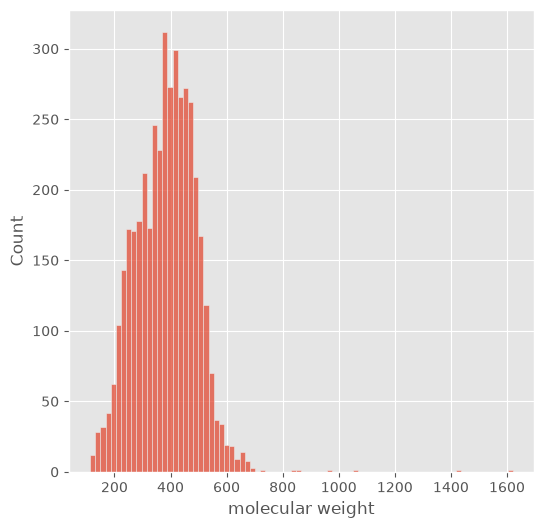

In [9]:
plt.figure(figsize= (6 , 6 ))
sns.histplot(data= df_final , x = df_final['Molwht'] , y  = None , hue = None  )
plt.xlabel('molecular weight')
plt.ylabel('Count')

In [ ]:

high_mwt = df_final[df_final['Molwht'] > 700]

print(high_mwt )

,CMPD_CHEMBLID,exp,smiles,mol,Molwht
364,CHEMBL1094250,3.48,C[C@@H](CNC(=O)c1c(O)c(O)cc2c(O)c(c(C)cc12)c3c...,<rdkit.Chem.rdchem.Mol object at 0x0000015D00A...,700.788
442,CHEMBL1214185,1.80,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,<rdkit.Chem.rdchem.Mol object at 0x0000015D00A...,837.058
905,CHEMBL443684,0.64,CC1(C)CCC(=C(CN2CCN(CC2)c3ccc(cc3)C(=O)NS(=O)(...,<rdkit.Chem.rdchem.Mol object at 0x0000015D00A...,974.634
1236,CHEMBL2170837,4.20,CCn1c(C)c(C(=O)O)c(c2cccc(c2)N3CCN(CC3)c4ccc(N...,<rdkit.Chem.rdchem.Mol object at 0x0000015D00A...,1065.703
1397,CHEMBL1200558,-0.46,CC[C@H](C)[C@H](N)C1=N[C@@H](CS1)C(=O)N[C@@H](...,<rdkit.Chem.rdchem.Mol object at 0x0000015D00A...,1422.720
1646,CHEMBL3545252,3.40,O.O.O.CC(=O)O[C@@]12CO[C@@H]1C[C@H](O)[C@]3(C)...,<rdkit.Chem.rdchem.Mol object at 0x0000015D00A...,861.935
3592,CHEMBL387675,-0.94,CCCCCCCCCC(=O)N[C@@H](Cc1c[nH]c2ccccc12)C(=O)N...,<rdkit.Chem.rdchem.Mol object at 0x0000015D00A...,1620.693
3780,CHEMBL163,4.30,CC(C)[C@H](NC(=O)N(C)Cc1csc(n1)C(C)C)C(=O)N[C@...,<rdkit.Chem.rdchem.Mol object at 0x0000015D00A...,720.962


In [11]:
high_mwt.shape


(8, 5)

<IPython.core.display.Image object>


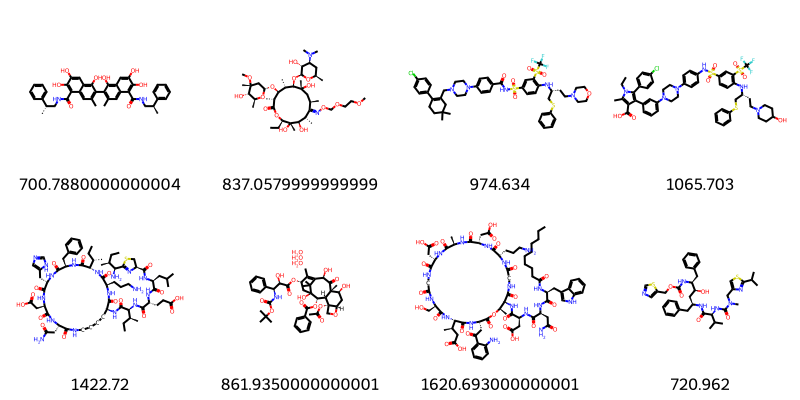

In [12]:
Img = Draw.MolsToGridImage(high_mwt['mol'] , molsPerRow=4, subImgSize=(200,200),legends=[str(x) for x in high_mwt['Molwht']])


print(Img )
Img

**remove the lourd molecule**

In [13]:
smiles = high_mwt['smiles']
df_final = df_final[~df_final['smiles'].isin(smiles)]
df_final.head()




,CMPD_CHEMBLID,exp,smiles,mol,Molwht
0,CHEMBL596271,3.54,Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14,<rdkit.Chem.rdchem.Mol object at 0x0000015D008...,340.858
1,CHEMBL1951080,-1.18,COc1cc(OC)c(cc1NC(=O)CSCC(=O)O)S(=O)(=O)N2C(C)...,<rdkit.Chem.rdchem.Mol object at 0x0000015D009...,494.591
2,CHEMBL1771,3.69,COC(=O)[C@@H](N1CCc2sccc2C1)c3ccccc3Cl,<rdkit.Chem.rdchem.Mol object at 0x0000015D009...,321.829
3,CHEMBL234951,3.37,OC[C@H](O)CN1C(=O)C(Cc2ccccc12)NC(=O)c3cc4cc(C...,<rdkit.Chem.rdchem.Mol object at 0x0000015D009...,419.890
4,CHEMBL565079,3.10,Cc1cccc(C[C@H](NC(=O)c2cc(nn2C)C(C)(C)C)C(=O)N...,<rdkit.Chem.rdchem.Mol object at 0x0000015D009...,381.480


In [14]:
df_final.shape


(4192, 5)

In [15]:
df_final.head()


,CMPD_CHEMBLID,exp,smiles,mol,Molwht
0,CHEMBL596271,3.54,Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14,<rdkit.Chem.rdchem.Mol object at 0x0000015D008...,340.858
1,CHEMBL1951080,-1.18,COc1cc(OC)c(cc1NC(=O)CSCC(=O)O)S(=O)(=O)N2C(C)...,<rdkit.Chem.rdchem.Mol object at 0x0000015D009...,494.591
2,CHEMBL1771,3.69,COC(=O)[C@@H](N1CCc2sccc2C1)c3ccccc3Cl,<rdkit.Chem.rdchem.Mol object at 0x0000015D009...,321.829
3,CHEMBL234951,3.37,OC[C@H](O)CN1C(=O)C(Cc2ccccc12)NC(=O)c3cc4cc(C...,<rdkit.Chem.rdchem.Mol object at 0x0000015D009...,419.890
4,CHEMBL565079,3.10,Cc1cccc(C[C@H](NC(=O)c2cc(nn2C)C(C)(C)C)C(=O)N...,<rdkit.Chem.rdchem.Mol object at 0x0000015D009...,381.480


Text(0, 0.5, 'Count')

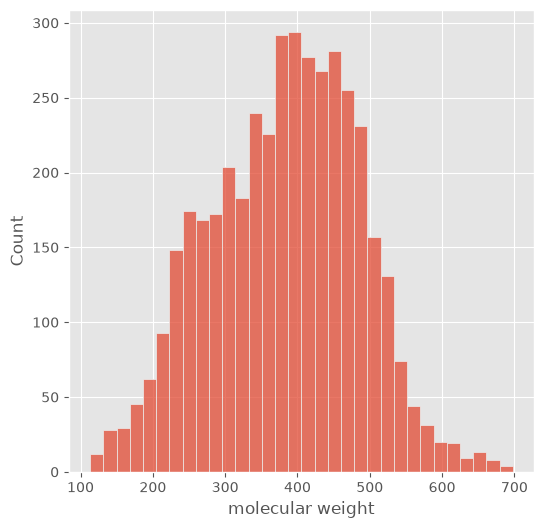

In [16]:
plt.figure(figsize= (6 , 6 ))
sns.histplot(data= df_final , x = df_final['Molwht'] , y  = None , hue = None  )
plt.xlabel('molecular weight')
plt.ylabel('Count')

In [17]:
df_final = df_final.reset_index(drop = True)



In [18]:
def found_atoms(df: pd.DataFrame) -> set[str]:
    unique_atoms = set()
    for mol in df['mol']:
        for atom in mol.GetAtoms():
            unique_atoms.add(atom.GetSymbol())
    return unique_atoms

found_atoms(df_final)

{'B', 'Br', 'C', 'Cl', 'F', 'I', 'N', 'O', 'P', 'S', 'Se', 'Si'}

In [19]:
import os as _os
from IPython.display import display as _display, FileLink as _FileLink

if 'show_and_export' not in globals():
    MOL_VIZ_OUTPUT_DIR = globals().get('MOL_VIZ_OUTPUT_DIR', './mol_viz_exports')
    _os.makedirs(MOL_VIZ_OUTPUT_DIR, exist_ok=True)

    def show_and_export(fig, filename: str, output_dir: str = MOL_VIZ_OUTPUT_DIR):
        fig.show(config={'displayModeBar': True, 'scrollZoom': True})
        filepath = _os.path.join(output_dir, filename)
        fig.write_html(filepath, include_plotlyjs='cdn', full_html=True)
        print(f"Figure sauvegardee -> {filepath}")
        _display(_FileLink(filepath))
        return filepath

In [20]:
from rdkit import Chem
from rdkit.Chem import AllChem
import plotly.graph_objects as go


ATOM_COLORS = {
    'C': 'grey', 'N': 'blue', 'O': 'red', 'S': 'gold',
    'Cl': 'green', 'F': 'lightgreen', 'Br': 'darkred',
    'P': 'orange', 'H': 'white',
}

def plot_molecule_graph_3d(sample_idx: int, marker_size: int = 10, add_hydrogens: bool = False):

    row = df_final.iloc[sample_idx]
    smile = row['smiles']

    mol = Chem.MolFromSmiles(smile)
    if add_hydrogens:
        mol = Chem.AddHs(mol)


    mol = Chem.Mol(mol)
    embed_status = AllChem.EmbedMolecule(mol, randomSeed=42)
    if embed_status != 0:
        AllChem.EmbedMolecule(mol, useRandomCoords=True, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)

    conf = mol.GetConformer()
    coords = conf.GetPositions()  # shape (n_atoms, 3)
    symbols = [atom.GetSymbol() for atom in mol.GetAtoms()]

    fig = go.Figure()


    edge_x, edge_y, edge_z = [], [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        p1, p2 = coords[i], coords[j]
        edge_x += [p1[0], p2[0], None]
        edge_y += [p1[1], p2[1], None]
        edge_z += [p1[2], p2[2], None]

    fig.add_trace(
        go.Scatter3d(
            x=edge_x, y=edge_y, z=edge_z,
            mode='lines',
            line=dict(color='rgba(80,80,80,0.6)', width=4),
            name='bonds', hoverinfo='none', showlegend=False,
        )
    )


    for element in sorted(set(symbols)):
        mask = [s == element for s in symbols]
        fig.add_trace(
            go.Scatter3d(
                x=coords[mask, 0], y=coords[mask, 1], z=coords[mask, 2],
                mode='markers+text',
                marker=dict(size=marker_size, color=ATOM_COLORS.get(element, 'purple'), opacity=0.9),
                text=[element] * sum(mask), textposition='top center',
                name=element,
            )
        )

    exp_txt = f'{row.exp:.2f}' if pd.notna(row.exp) else 'NA'
    fig.update_layout(
        title=f'Graphe 3D moleculaire — idx:{sample_idx}; CHEMBL:{row.CMPD_CHEMBLID}; exp(logD)={exp_txt}',
        height=750, legend_title_text='atome',
        scene=dict(xaxis_title='x (Å)', yaxis_title='y (Å)', zaxis_title='z (Å)'),
    )

    html_filename = f'mol_graph_{sample_idx}_{row.CMPD_CHEMBLID}.html'
    show_and_export(fig, html_filename)


for i in range(min(3, len(df_final))):
    plot_molecule_graph_3d(i)

[13:25:50] Molecule does not have explicit Hs. Consider calling AddHs()
[13:25:50] Molecule does not have explicit Hs. Consider calling AddHs()


Figure sauvegardee -> ./mol_viz_exports\mol_graph_0_CHEMBL596271.html


c:\Users\pc\Downloads\GNN prediction solubility\mol_viz_exports\mol_graph_0_CHEMBL596271.html

[13:25:52] Molecule does not have explicit Hs. Consider calling AddHs()
[13:25:52] Molecule does not have explicit Hs. Consider calling AddHs()


Figure sauvegardee -> ./mol_viz_exports\mol_graph_1_CHEMBL1951080.html


c:\Users\pc\Downloads\GNN prediction solubility\mol_viz_exports\mol_graph_1_CHEMBL1951080.html

[13:25:52] Molecule does not have explicit Hs. Consider calling AddHs()
[13:25:52] Molecule does not have explicit Hs. Consider calling AddHs()


Figure sauvegardee -> ./mol_viz_exports\mol_graph_2_CHEMBL1771.html


c:\Users\pc\Downloads\GNN prediction solubility\mol_viz_exports\mol_graph_2_CHEMBL1771.html

In [21]:
def count_atoms(df: pd.DataFrame) -> pd.DataFrame:
    atom_counts = []

    for _, row in df.iterrows():
        atom_counts.extend(
            {'exp': row['exp'], 'atom': atom.GetSymbol()}
            for atom in row['mol'].GetAtoms()
        )

    return (
        pd.DataFrame(atom_counts)
        .groupby(['exp', 'atom'])
        .size()
        .reset_index(name='count')
        .sort_values(['exp', 'atom'])
        .reset_index(drop=True)
    )

atom_counts = count_atoms(df_final)
atom_counts

,exp,atom,count
0,-1.50,C,9
1,-1.50,F,2
2,-1.50,N,3
3,-1.50,O,4
4,-1.48,C,5
...,...,...,...
2926,4.50,Cl,1
2927,4.50,F,11
2928,4.50,N,14
2929,4.50,O,5


In [22]:
def count_atoms(df : pd.DataFrame) -> pd.DataFrame :
    atomes_list = []
    for mol in df_final['mol'] :
        for atom in mol.GetAtoms() :
            atomes_list.append(atom.GetSymbol())
    return atomes_list
count  = count_atoms(df_final)
from collections import Counter
Counter(count)

Counter({'C': 83065,
         'N': 14505,
         'O': 10679,
         'F': 1760,
         'S': 1580,
         'Cl': 1288,
         'Br': 100,
         'I': 7,
         'B': 6,
         'P': 3,
         'Si': 1,
         'Se': 1})

In [23]:
atom_counts = {
         'N': 14505,
         'O': 10679,
         'F': 1760,
         'S': 1580,
         'Cl': 1288,
         'Br': 100,
         'I': 7,
         'B': 6, 
         'P': 3,
         'Si': 1,
         'Se': 1}

In [24]:
df_freq = pd.DataFrame(atom_counts.items() , columns = ['atomes' , 'Count'] ).sort_values('Count' , ascending = False)


In [25]:
df_freq.head()

,atomes,Count
0,N,14505
1,O,10679
2,F,1760
3,S,1580
4,Cl,1288


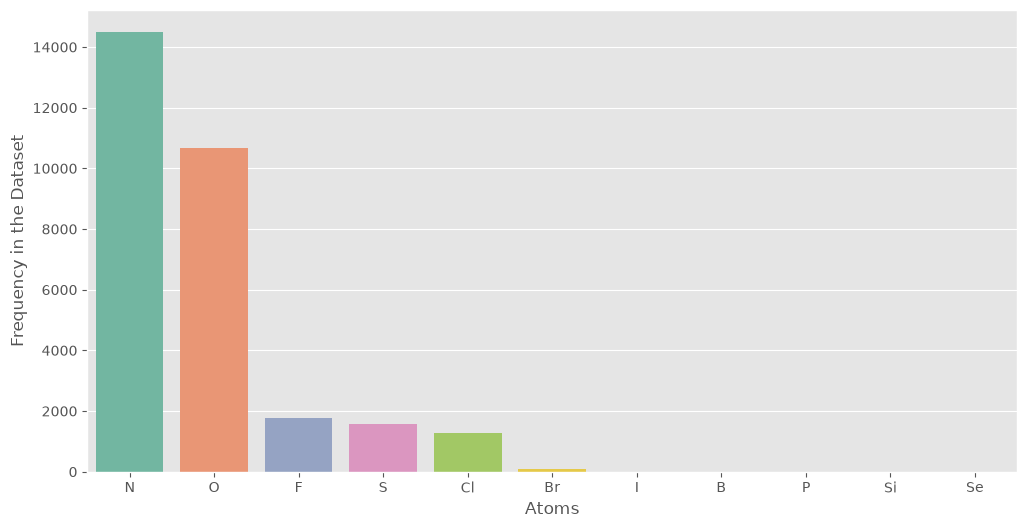

In [26]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_freq,
    x='atomes',
    y='Count',
    hue='atomes',
    palette='Set2',
    legend=False
)

plt.ylabel('Frequency in the Dataset')
plt.xlabel('Atoms')
plt.show()

**cout the numbers of atmos who exist in our sample molecule**

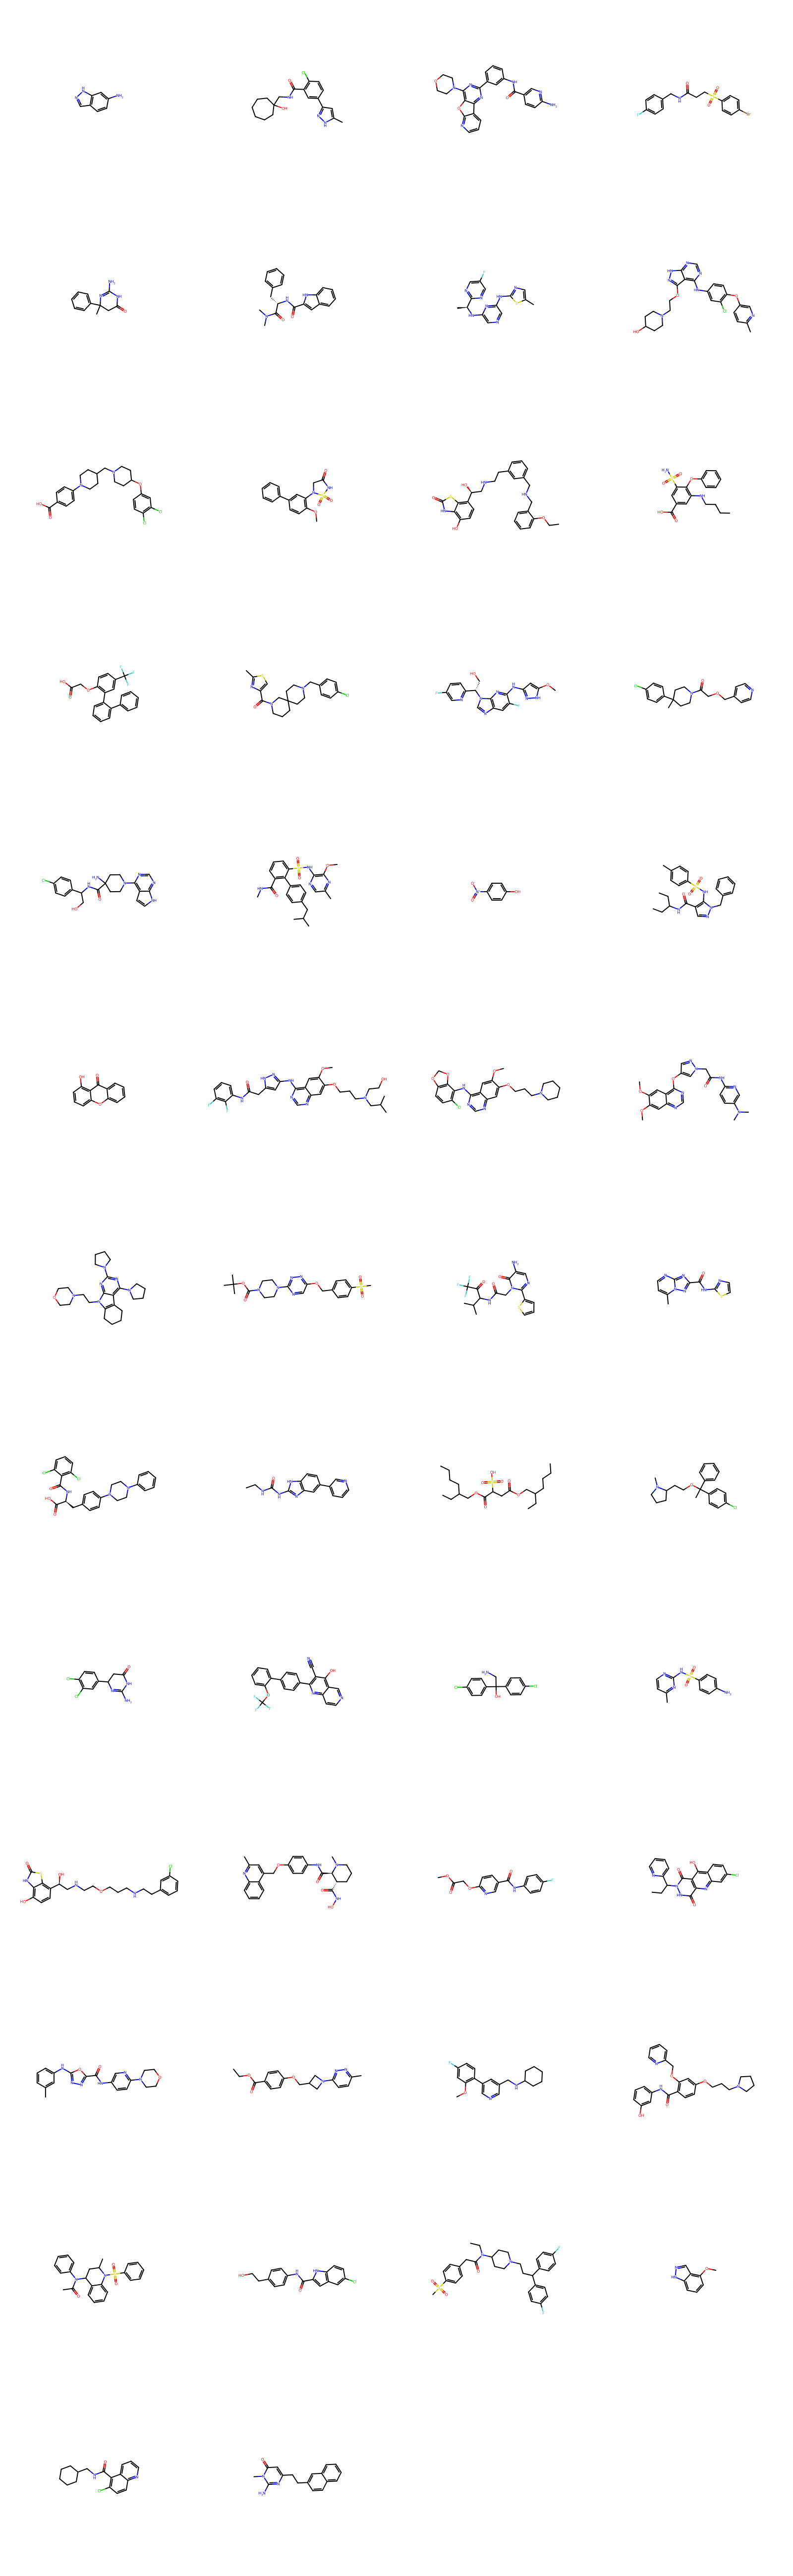

In [27]:
b_smiles = df_final['smiles']
b_mols = [Chem.MolFromSmiles(x) for x in b_smiles[-50:]]
img=Draw.MolsToGridImage(b_mols,molsPerRow=4,subImgSize=(400,400))
img
     

In [28]:

ref_atom_list = ['B', 'Br','Cl', 'F', 'I', 'N', 'O', 'P', 'S', 'Se', 'Si']
dict_2 = {}
for i in range(len(ref_atom_list)):
  count=0
  for mol in df_final["mol"]:
    all_atoms = set()
    for atom in mol.GetAtoms():
      a = atom.GetSymbol()
      all_atoms.add(a)
    if ref_atom_list[i] in all_atoms:
      count+= 1
    dict_2[ref_atom_list[i]] = count

**the meaning of 'N': 4039 , there are a 4039 mol has at least one atom o N**

In [29]:
dict_2

{'B': 6,
 'Br': 96,
 'Cl': 974,
 'F': 899,
 'I': 4,
 'N': 4039,
 'O': 3814,
 'P': 3,
 'S': 1352,
 'Se': 1,
 'Si': 1}

In [30]:
df_freq_2 = pd.DataFrame(dict_2.items(), columns = ['Atoms', 'Count']).sort_values('Count', ascending=False )
df_freq_2

,Atoms,Count
5,N,4039
6,O,3814
8,S,1352
2,Cl,974
3,F,899
1,Br,96
0,B,6
4,I,4
7,P,3
9,Se,1


C:\Users\pc\AppData\Local\Temp\ipykernel_21168\1325498318.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df_freq_2, x = 'Atoms', y = 'Count', palette = 'Set2')


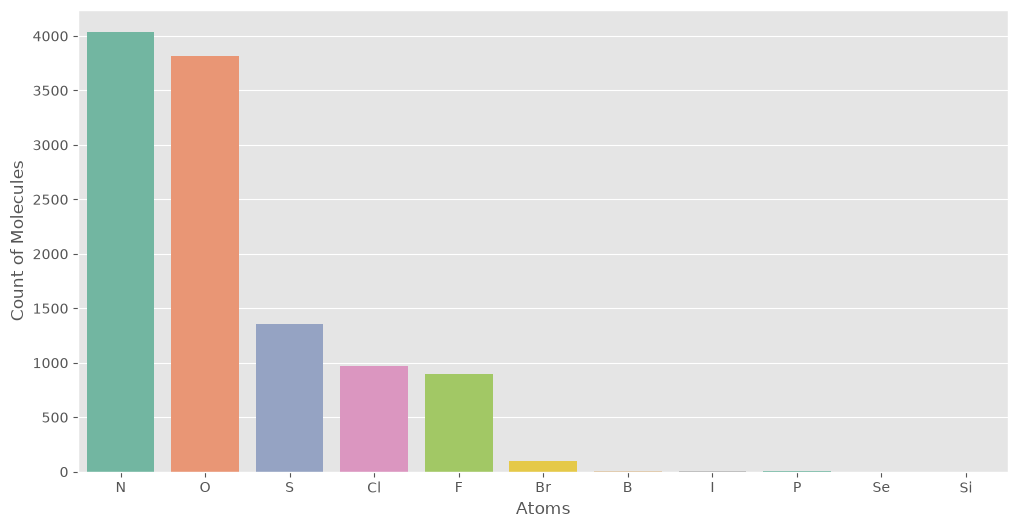

In [31]:


plt.figure(figsize=(12,6))
sns.barplot(df_freq_2, x = 'Atoms', y = 'Count', palette = 'Set2')
plt.ylabel('Count of Molecules')
plt.show()


# Generating the graphs 

In [32]:
df  =  pd.read_csv(r'C:\Users\pc\Downloads\GNN prediction solubility\Lipophilicity_final.csv')

In [33]:
df.head()

,CMPD_CHEMBLID,exp,smiles
0,CHEMBL596271,3.54,Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14
1,CHEMBL1951080,-1.18,COc1cc(OC)c(cc1NC(=O)CSCC(=O)O)S(=O)(=O)N2C(C)...
2,CHEMBL1771,3.69,COC(=O)[C@@H](N1CCc2sccc2C1)c3ccccc3Cl
3,CHEMBL234951,3.37,OC[C@H](O)CN1C(=O)C(Cc2ccccc12)NC(=O)c3cc4cc(C...
4,CHEMBL565079,3.10,Cc1cccc(C[C@H](NC(=O)c2cc(nn2C)C(C)(C)C)C(=O)N...


**generating the 3D representation by py3Dmol**

In [34]:

import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem

def plot_molecule_3d_py3dmol(sample_idx: int, style: str = 'stick',
                              add_hydrogens: bool = True, width: int = 600, height: int = 500):

    row = df_final.iloc[sample_idx]
    smile = row['smiles']

    mol = Chem.MolFromSmiles(smile)
    if add_hydrogens:
        mol = Chem.AddHs(mol)

    embed_status = AllChem.EmbedMolecule(mol, randomSeed=42)
    if embed_status != 0:
        AllChem.EmbedMolecule(mol, useRandomCoords=True, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)

  
    mol_block = Chem.MolToMolBlock(mol)

    viewer = py3Dmol.view(width=width, height=height)
    viewer.addModel(mol_block, 'mol')

    if style == 'stick':
        viewer.setStyle({'stick': {}})
    elif style == 'sphere':
        viewer.setStyle({'sphere': {}})
    elif style == 'line':
        viewer.setStyle({'line': {}})
    elif style == 'stick+sphere':
        viewer.setStyle({'stick': {'radius': 0.15}, 'sphere': {'scale': 0.25}})
    else:
        viewer.setStyle({'stick': {}})

    exp_txt = f'{row.exp:.2f}' if pd.notna(row.exp) else 'NA'
    print(f"idx:{sample_idx} | CHEMBL:{row.CMPD_CHEMBLID} | exp(logD)={exp_txt} | smiles={smile}")

    viewer.zoomTo()
    viewer.setBackgroundColor('black')
    return viewer.show()



for i in range(min(3, len(df_final))):
    plot_molecule_3d_py3dmol(i, style='stick+sphere')

idx:0 | CHEMBL:CHEMBL596271 | exp(logD)=3.54 | smiles=Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

idx:1 | CHEMBL:CHEMBL1951080 | exp(logD)=-1.18 | smiles=COc1cc(OC)c(cc1NC(=O)CSCC(=O)O)S(=O)(=O)N2C(C)CCc3ccccc23


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

idx:2 | CHEMBL:CHEMBL1771 | exp(logD)=3.69 | smiles=COC(=O)[C@@H](N1CCc2sccc2C1)c3ccccc3Cl


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [35]:
smile = df['smiles'][100]
smile

'CC1=CN([C@H]2CCCN(C2)S(=O)(=O)c3ccc(O)c(Oc4ccccc4)c3)C(=O)NC1=O'

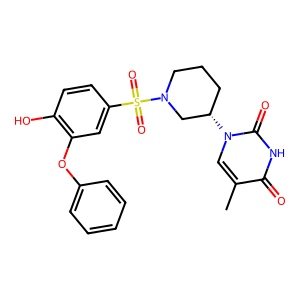

In [36]:
mol = Chem.MolFromSmiles(smile)
img = Draw.MolToImage(mol)
img

**in this output of this cell we have x , mean the Number of Atoms or Number of Nodes**

In [37]:
torch_g = from_smiles(smile , with_hydrogen= False)
torch_g


Data(x=[32, 9], edge_index=[2, 70], edge_attr=[70, 3], smiles='CC1=CN([C@H]2CCCN(C2)S(=O)(=O)c3ccc(O)c(Oc4ccccc4)c3)C(=O)NC1=O')

**the tnesor of this molecule**

In [38]:
torch_g.x

tensor([[ 6,  0,  4,  5,  3,  0,  4,  0,  0],
        [ 6,  0,  3,  5,  0,  0,  3,  1,  1],
        [ 6,  0,  3,  5,  1,  0,  3,  1,  1],
        [ 7,  0,  3,  5,  0,  0,  3,  1,  1],
        [ 6,  1,  4,  5,  1,  0,  4,  0,  1],
        [ 6,  0,  4,  5,  2,  0,  4,  0,  1],
        [ 6,  0,  4,  5,  2,  0,  4,  0,  1],
        [ 6,  0,  4,  5,  2,  0,  4,  0,  1],
        [ 7,  0,  3,  5,  0,  0,  4,  0,  1],
        [ 6,  0,  4,  5,  2,  0,  4,  0,  1],
        [16,  0,  4,  5,  0,  0,  4,  0,  0],
        [ 8,  0,  1,  5,  0,  0,  3,  0,  0],
        [ 8,  0,  1,  5,  0,  0,  3,  0,  0],
        [ 6,  0,  3,  5,  0,  0,  3,  1,  1],
        [ 6,  0,  3,  5,  1,  0,  3,  1,  1],
        [ 6,  0,  3,  5,  1,  0,  3,  1,  1],
        [ 6,  0,  3,  5,  0,  0,  3,  1,  1],
        [ 8,  0,  2,  5,  1,  0,  3,  0,  0],
        [ 6,  0,  3,  5,  0,  0,  3,  1,  1],
        [ 8,  0,  2,  5,  0,  0,  3,  0,  0],
        [ 6,  0,  3,  5,  0,  0,  3,  1,  1],
        [ 6,  0,  3,  5,  1,  0,  

In [39]:

print('the type of tensor :' , torch_g.x.dtype)

the type of tensor : torch.int64


In [40]:
torch_g.num_nodes

32

In [41]:
torch_g.num_node_features

9

**In PyTorch Geometric, the term edge represents a chemical bond connecting two atoms (nodes).**
**Row 1 (edge_index[0]): Source Node (the starting atom). , Row 2 (edge_index[1]): Target Node (the ending atom). ,Columns (70): Total number of directed edges in the graph**

In [42]:
torch_g.edge_index

tensor([[ 0,  1,  1,  1,  2,  2,  3,  3,  3,  4,  4,  4,  5,  5,  6,  6,  7,  7,
          8,  8,  8,  9,  9, 10, 10, 10, 10, 11, 12, 13, 13, 13, 14, 14, 15, 15,
         16, 16, 16, 17, 18, 18, 18, 19, 19, 20, 20, 20, 21, 21, 22, 22, 23, 23,
         24, 24, 25, 25, 26, 26, 27, 27, 27, 28, 29, 29, 30, 30, 30, 31],
        [ 1,  0,  2, 30,  1,  3,  2,  4, 27,  3,  5,  9,  4,  6,  5,  7,  6,  8,
          7,  9, 10,  4,  8,  8, 11, 12, 13, 10, 10, 10, 14, 26, 13, 15, 14, 16,
         15, 17, 18, 16, 16, 19, 26, 18, 20, 19, 21, 25, 20, 22, 21, 23, 22, 24,
         23, 25, 20, 24, 13, 18,  3, 28, 29, 27, 27, 30,  1, 29, 31, 30]])

***the features of that 35 bonds [Bond Type, Stereochemistry, Is Conjugated])**

In [43]:
torch_g.edge_attr

tensor([[ 1,  0,  0],
        [ 1,  0,  0],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [ 1,  0,  0],
        [12,  0,  1],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 2,  0,  0],
        [ 2,  0,  0],
        [ 1,  0,  0],
        [ 2,  0,  0],
        [ 2,  0,  0],
        [ 1,  0,  0],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [ 1,  0,  1],
        [12,  0,  1],
        [ 1,  0,  1],
        [12,  0,  1],
        [ 1,  0,  1],
        [12,  0,  1],
        [ 1,  0,  1],
        [ 1,  0,  1],
        [ 

**Convert our graph generated a networkX graph for analysis**
**networkx is used for manimualtio and visulisation of graoh (nodes , edges , features of this proprities)**

In [44]:
G = to_networkx(torch_g)

In [45]:
G.number_of_nodes()
G.number_of_edges()

70

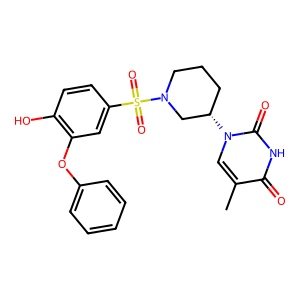

In [46]:
img

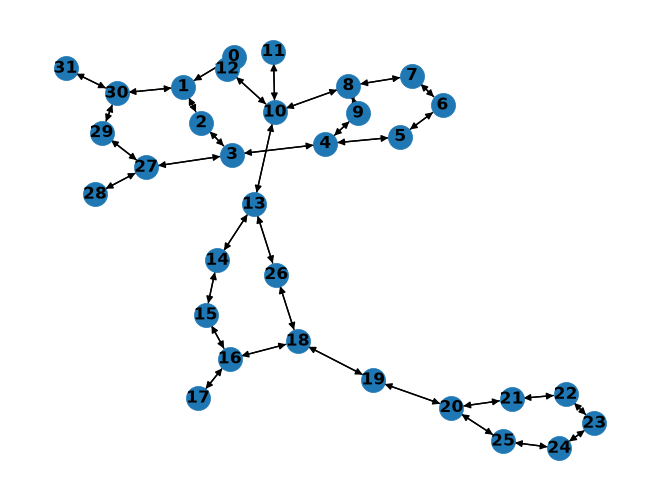

In [63]:
nx.draw( G  , with_labels= True, font_weight= 'bold')

**Generate Graphs for the Whole Dataset**

In [48]:


graph_list = []
for i, smile in enumerate(df_final['smiles']):
  g = from_smiles(smile)
  g.x = g.x.float()
  y = torch.tensor(df_final['exp'][i], dtype=torch.float).view(1, -1)
  g.y = y
  graph_list.append(g) 

In [49]:
type(graph_list[0]) 

torch_geometric.data.data.Data

In [50]:
graph_list[1].x
len(graph_list[1].x)


33

In [51]:
graph_list[1].y

tensor([[-1.1800]])

**Class Save ur graphical data in CPU**

In [52]:
class MyOwnDataset(InMemoryDataset):
    def __init__(self, root, transform=None, pre_transform=None, pre_filter=None):
        super().__init__(root, transform, pre_transform, pre_filter)
        self.load(self.processed_paths[0])

    @property
    def raw_file_names(self):
        return 'Lipophilicity.csv'

    @property
    def processed_file_names(self):
        return 'data.dt'

    def download(self):
 
        pass

    def process(self):
        # Read data into huge `Data` list.
        graph_list = []
        for i, smile in enumerate(df_final['smiles']):
          g = from_smiles(smile)
          g.x = g.x.float()
          y = torch.tensor(df_final['exp'][i], dtype=torch.float).view(1, -1)
          g.y = y
          graph_list.append(g)


        data_list = graph_list

        if self.pre_filter is not None:
            data_list = [data for data in data_list if self.pre_filter(data)]

        if self.pre_transform is not None:
            data_list = [self.pre_transform(data) for data in data_list]

        self.save(data_list, self.processed_paths[0])
     

     

In [53]:
root = MyOwnDataset(r"C:\Users\pc\Downloads\GNN prediction solubility")

In [54]:
root[23]


Data(x=[31, 9], edge_index=[2, 68], edge_attr=[68, 3], smiles='OC(=O)c1cccc(c1)N2CCC(CN3CCC(CC3)Oc4ccc(Cl)c(Cl)c4)CC2', y=[1, 1])

**Creation the model_neural and train it**

In [55]:

train_ratio = 0.80  
dataset_size = len(graph_list)
train_size = int(train_ratio * dataset_size)
test_size = dataset_size - train_size


generator1 = torch.Generator().manual_seed(42)
train_dataset, test_dataset = random_split(graph_list, [train_size, test_size], generator=generator1)

In [56]:
df.iloc[train_dataset.indices]

,CMPD_CHEMBLID,exp,smiles
3654,CHEMBL424451,3.96,COc1ccc(C)c(NC(=O)CC23CC4CC(CC(C4)C2)C3)c1
195,CHEMBL139347,2.40,Nc1nc(N)nc(n1)c2cccc(c2)C(F)(F)F
1988,CHEMBL2158833,1.10,OC(=O)c1ccc(CN2CCC(CN3CCC(CC3)Oc4ccc(Cl)c(Cl)c...
242,CHEMBL1201373,1.07,CC[C@H](C)C(=O)O[C@H]1C[C@@H](C)C=C2C=C[C@H](C...
310,CHEMBL1800526,2.92,COc1ccnc(CCc2nc3cc(Br)cnc3[nH]2)c1
...,...,...,...
1157,CHEMBL70824,2.16,CN(C)CCCN(C)S(=O)(=O)c1ccc(Nc2nccc(n2)c3cnc4cc...
829,CHEMBL211631,0.49,COc1cccc2c(ccnc12)c3c(C)n(CC(=O)O)c4ccc(C)cc34
40,CHEMBL168899,1.40,OB1N(C(=O)Nc2ccccc12)c3ccccc3
3768,CHEMBL1500992,3.20,O=C(CSc1ccccc1)N2CCN(CC2)c3ccccc3


In [57]:

test = df.iloc[test_dataset.indices]
test.to_csv('test_set.csv', index=None)

In [58]:

train_loader = DataLoader(train_dataset, batch_size=96, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=96)

In [59]:
graph_list[0]

Data(x=[24, 9], edge_index=[2, 54], edge_attr=[54, 3], smiles='Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14', y=[1, 1])

In [60]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = AttentiveFP(in_channels=9, hidden_channels=64, out_channels=1,
                     edge_dim=3, num_layers=4, num_timesteps=2,
                     dropout=0.2).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=10**-2.5,weight_decay=10**-5)



In [61]:
def train():
    total_loss = total_samples = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        loss = F.mse_loss(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += float(loss) * data.num_graphs
        total_samples += data.num_graphs
    return sqrt(total_loss / total_samples)
@torch.no_grad()
def test(loader):
    mse = []
    model.eval()
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.edge_attr,data.batch)
        l = F.mse_loss(out, data.y, reduction='none').cpu()
        mse.append(l)
    rmse = float(torch.cat(mse, dim=0).mean().sqrt())
    return rmse

In [62]:
score_train = []
score_test = []
epochs = 200
model.reset_parameters()
for epoch in range(epochs):
    train_rmse = train()
    test_rmse = test(test_loader)
    score_train.append(train_rmse)
    score_test.append(test_rmse)
    print(f'Epoch: {epoch:03d}, Train Loss: {train_rmse:.4f} '
          f'Test Loss: {test_rmse:.4f}')
plt.plot(range(epochs), score_train, c='goldenrod')
plt.plot(range(epochs), score_test, c = 'blue')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.legend(['train', 'test'])
     

C:\Users\pc\AppData\Local\Temp\ipykernel_21168\3242684124.py:10: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  total_loss += float(loss) * data.num_graphs


Epoch: 000, Train Loss: 1.4880 Test Loss: 1.1613
Epoch: 001, Train Loss: 1.1806 Test Loss: 1.1632
Epoch: 002, Train Loss: 1.1694 Test Loss: 1.1544
Epoch: 003, Train Loss: 1.1632 Test Loss: 1.1302
Epoch: 004, Train Loss: 1.1555 Test Loss: 1.1085
Epoch: 005, Train Loss: 1.1332 Test Loss: 1.1556
Epoch: 006, Train Loss: 1.1268 Test Loss: 1.1509
Epoch: 007, Train Loss: 1.1096 Test Loss: 1.1091
Epoch: 008, Train Loss: 1.0930 Test Loss: 1.0711
Epoch: 009, Train Loss: 1.0878 Test Loss: 1.0942
Epoch: 010, Train Loss: 1.0705 Test Loss: 1.0441
Epoch: 011, Train Loss: 1.0584 Test Loss: 1.0302
Epoch: 012, Train Loss: 1.0374 Test Loss: 1.0028
Epoch: 013, Train Loss: 0.9916 Test Loss: 1.0152
Epoch: 014, Train Loss: 0.9889 Test Loss: 0.9754
Epoch: 015, Train Loss: 0.9361 Test Loss: 0.8829
Epoch: 016, Train Loss: 0.8875 Test Loss: 0.8221
Epoch: 017, Train Loss: 0.8905 Test Loss: 0.8238
Epoch: 018, Train Loss: 0.8510 Test Loss: 0.8586
Epoch: 019, Train Loss: 0.8301 Test Loss: 0.8012
Epoch: 020, Train Lo

KeyboardInterrupt: 

**found the best hyperparametres of the model by optuna**

In [ ]:
import optuna

In [ ]:
def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.0, 0.5, step=0.1)
    num_layers = trial.suggest_int("num_layers", 2, 6)
    hidden_channels = trial.suggest_int("hidden_channels", 32, 192, step=32)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "RMSprop", "SGD"])
    batch_size = trial.suggest_int("batch_size", 16, 128, step=16)

    generator = torch.Generator().manual_seed(42)
    train_dataset, test_dataset = random_split(
        graph_list, [train_size, test_size], generator=generator
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = AttentiveFP(
        in_channels=9,
        hidden_channels=hidden_channels,
        out_channels=1,
        edge_dim=3,
        num_layers=num_layers,
        num_timesteps=2,
        dropout=dropout,
    ).to(device)

    optimizer_class = getattr(torch.optim, optimizer_name)
    optimizer = optimizer_class(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )

    def train():
        total_loss = total_examples = 0
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            out = model(data.x, data.edge_index, data.edge_attr, data.batch)
            loss = F.mse_loss(out, data.y)
            loss.backward()
            optimizer.step()
            total_loss += float(loss) * data.num_graphs
            total_examples += data.num_graphs
        return sqrt(total_loss / total_examples)
    @torch.no_grad()
    def test(loader):
        mse = []
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.edge_attr,data.batch)
            l = F.mse_loss(out, data.y, reduction='none').cpu()
            mse.append(l)
        rmse = float(torch.cat(mse, dim=0).mean().sqrt())
        return rmse
    
    for epoch in range(50):
        train_rmse = train()
        test_rmse = test(test_loader)

        trial.report(test_rmse, epoch)
    return test_rmse 


In [ ]:
study = optuna.create_study(direction = 'minimize' , study_name = 'hyperparameter-tune-afp', storage = 'sqlite:///htune_afp.db')
N_TRIALS =50
study.optimize(objective , n_trials = N_TRIALS)


**im runed this part of code on gpu and i found this best_parms**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [ ]:
best_params= {'lr': 0.0008146231558860833, 'weight_decay': 3.383308998994097e-05, 'dropout': 0.1, 'num_layers': 5, 'hidden_channels': 192, 'optimizer': 'Adam', 'batch_size': 48}
# recreation du split identique
generator = torch.Generator().manual_seed(42)
train_dataset, test_dataset = random_split(graph_list, [train_size, test_size], generator=generator)
train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'])

best_model = AttentiveFP(
    in_channels=9,
    hidden_channels=best_params['hidden_channels'],
    out_channels=1,
    edge_dim=3,
    num_layers=best_params['num_layers'],
    num_timesteps=2,
    dropout=best_params['dropout'],
).to(device)

optimizer_class = getattr(torch.optim, best_params['optimizer'])
optimizer = optimizer_class(
    best_model.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay']
)
def train():
    total_loss = total_examples = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = best_model(data.x, data.edge_index, data.edge_attr, data.batch)
        loss = F.mse_loss(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += float(loss) * data.num_graphs
        total_examples += data.num_graphs
    return sqrt(total_loss / total_examples)

@torch.no_grad()
def test(loader):
    mse = []
    for data in loader:
        data = data.to(device)
        out = best_model(data.x, data.edge_index, data.edge_attr, data.batch)
        l = F.mse_loss(out, data.y, reduction='none').cpu()
        mse.append(l)
    return float(torch.cat(mse, dim=0).mean().sqrt())

for epoch in range(80):
    train_rmse = train()
    test_rmse = test(test_loader)
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: train_rmse={train_rmse:.4f}, test_rmse={test_rmse:.4f}")

print(f"Modele final sauvegarde. Test RMSE final: {test_rmse:.4f}")
torch.save(best_model.state_dict(), r'C:\Users\pc\Downloads\GNN prediction solubility\best_afp_model.pt')

C:\Users\pc\AppData\Local\Temp\ipykernel_23064\3917225689.py:31: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  total_loss += float(loss) * data.num_graphs


Epoch 0: train_rmse=1.2730, test_rmse=1.1527
Epoch 10: train_rmse=0.9344, test_rmse=0.8860
Epoch 20: train_rmse=0.7847, test_rmse=0.7567
Epoch 30: train_rmse=0.6626, test_rmse=0.6855
Epoch 40: train_rmse=0.6143, test_rmse=0.6995
Epoch 50: train_rmse=0.5513, test_rmse=0.6472
Epoch 60: train_rmse=0.5138, test_rmse=0.6109
Epoch 70: train_rmse=0.4750, test_rmse=0.6273
Modele final sauvegarde. Test RMSE final: 0.6070


In [ ]:
@torch.no_grad()
def eval_new_data(loader):
    output = []
    smi = []
    best_model.eval()
    for data in loader:
        data = data.to(device)
        out = best_model(data.x, data.edge_index, data.edge_attr, data.batch)
        concatenated_data = torch.cat((out, data.y.view(-1, 1)), dim=1)
        output.append(concatenated_data.cpu())
        smi.extend(data.smiles)  

    stacked_output = torch.cat(output, dim=0).numpy()  # -> numpy pour pandas

    results = pd.DataFrame(stacked_output, columns=['pred', 'actual'])
    results['smiles'] = smi  # ajout direct de la colonne liste

    r2 = r2_score(results['actual'], results['pred'])
    print(f"The R2 score is {r2}")
    return results


test_res = eval_new_data(test_loader)

The R2 score is 0.7640355825424194


In [ ]:
torch.save(best_model,  r'C:\Users\pc\Downloads\GNN prediction solubility\best_afp_model.pth')


In [ ]:
test_res = pd.read_csv(r'C:\Users\pc\Downloads\GNN prediction solubility\test_results.csv')

In [ ]:
train_res = eval_new_data(train_loader)

The R2 score is 0.914699137210846


Text(0, 0.5, 'the predictor values')

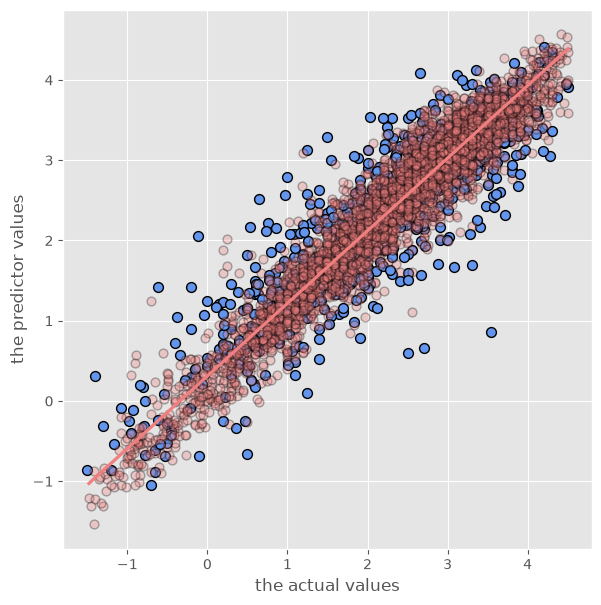

In [ ]:
fig = plt.figure(figsize = (15 , 7))
grid = plt.GridSpec(1 ,2 , wspace=0.2 , hspace = 0.2)
ax1 = plt.subplot(grid[0, 0])
plt.scatter(test_res['actual'],test_res['pred'], color='cornflowerblue', label='Test', linewidths=1, edgecolors='black', s=50)
sns.regplot(data = train_res, x = 'actual',y = 'pred', color='lightcoral', label='Train', scatter_kws={'s':40, 'alpha':0.3, 'edgecolor':'black'})
plt.xlabel('the actual values')
plt.ylabel('the predictor values')

In [ ]:

test_res['abs_error'] = abs(test_res['actual'] - test_res['pred'])


In [ ]:
test_res.head()

In [ ]:
test_res.to_csv(
    r'C:\Users\pc\Downloads\GNN prediction solubility\test_results.csv',
    index=False
)

In [ ]:
test_results= pd.read_csv(r'C:\Users\pc\Downloads\GNN prediction solubility\test_results.csv')

In [ ]:

test_results.head()

,pred,actual,smiles,abs_error
0,2.459884,1.28,CCCN(CCO)CCCOc1cc2ncnc(Nc3cc(CC(=O)Nc4cccc(F)c...,1.179884
1,3.096613,3.09,OCc1ccc2ccn(c3cc(NC4CC4)n5ncc(C#N)c5n3)c2c1,0.006613
2,0.308639,-1.41,CC(=O)Nc1cccc2c1c(Oc3ccc(Cl)cc3)c(C)n2CC(=O)O,1.718638
3,2.064316,1.90,CN1CCCC(COc2nccc(Nc3cc(NC(=O)c4ccnc(c4)N5CCOCC...,0.164316
4,4.062276,4.20,CC(C)C[C@H](CO)Nc1nc(SCc2ccccc2)nc3NC(=O)Sc13,0.137724


In [ ]:

test_results = test_results.sort_values('abs_error', ascending=False)
mols = [Chem.MolFromSmiles(x) for x in test_results['smiles'][:8]]

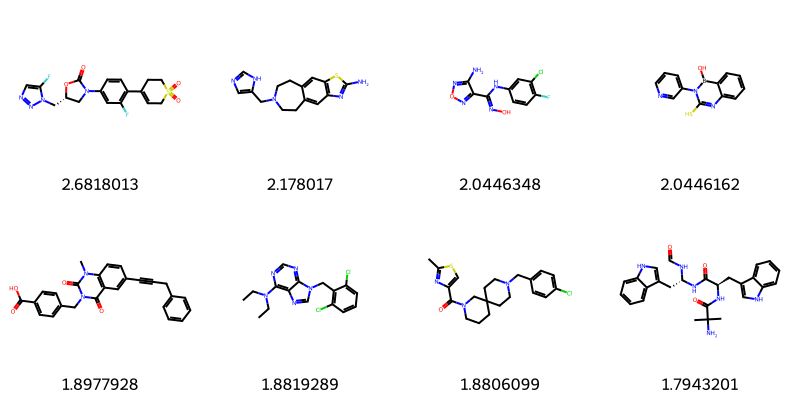

In [ ]:


img=Draw.MolsToGridImage(mols,molsPerRow=4,subImgSize=(200,200),legends=[str(x) for x in test_results['abs_error']])
img

In [ ]:
test_results.tail(8)

,pred,actual,smiles,abs_error
758,0.755108,0.76,CCS(=O)(=O)c1ccc(c(C)c1)c2cc(ccc2CCC(=O)O)C(F)...,0.004892
415,3.165982,3.17,C[C@H](NC(=O)C)c1ccc(Nc2ncc3cc(ccc3n2)c4ccncc4...,0.004018
512,4.256440,4.26,CN1C(=O)N(CC2CC2)c3nn(Cc4ccnc5ccc(Cl)cc45)c(c6...,0.003560
778,3.202987,3.20,Fc1cccc(Nc2oc(nn2)C(=O)Nc3ccc(nc3)N4CCOCC4)c1,0.002987
765,3.252832,3.25,CN1CCN(CC1)S(=O)(=O)c2ccc(c3cnc(N)c(n3)C(=O)Nc...,0.002831
222,3.439065,3.44,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN(C)[C@H](C)C...,0.000935
640,2.959391,2.96,CNc1c(Br)cnc2[nH]c(nc12)c3ccc(OCCCN4CCOCC4)cc3,0.000609
316,2.900522,2.90,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN(C)C,0.000522


In [ ]:
import torch
import torch.nn.functional as F
from math import sqrt
from torch.utils.data import SubsetRandomSampler
from torch_geometric.loader import DataLoader
from torch_geometric.nn import AttentiveFP
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score


def train_one_epoch(model, optimizer, loader):
    model.train()
    total_loss = total_examples = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        loss = F.mse_loss(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += float(loss) * data.num_graphs
        total_examples += data.num_graphs
    return sqrt(total_loss / total_examples)


@torch.no_grad()
def test_rmse_fn(model, loader):
    model.eval()
    mse = []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        l = F.mse_loss(out, data.y, reduction='none').cpu()
        mse.append(l)
    return float(torch.cat(mse, dim=0).mean().sqrt())


@torch.no_grad()
def evaluate_r2(model, loader):
    model.eval()
    preds, targets = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        preds.append(out.cpu())
        targets.append(data.y.cpu())
    preds = torch.cat(preds, dim=0).numpy()
    targets = torch.cat(targets, dim=0).numpy()
    return r2_score(targets, preds)


if __name__ == '__main__':
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    best_params ={'lr': 0.0008146231558860833, 'weight_decay': 3.383308998994097e-05, 'dropout': 0.1, 'num_layers': 5, 'hidden_channels': 192, 'optimizer': 'Adam', 'batch_size': 48}

    print("Best hyperparameters used for K-Fold:", best_params)

    k_folds = 5
    epochs = 200
    results = []
    kfold = KFold(n_splits=k_folds, shuffle=True, random_state=50)

    for fold, (train_ids, test_ids) in enumerate(kfold.split(graph_list)):
        print(f'--- FOLD {fold} ---')

        train_subsampler = SubsetRandomSampler(train_ids)
        test_subsampler = SubsetRandomSampler(test_ids)
        train_loader = DataLoader(graph_list, batch_size=best_params['batch_size'], sampler=train_subsampler)
        test_loader = DataLoader(graph_list, batch_size=best_params['batch_size'], sampler=test_subsampler)

        model = AttentiveFP(
            in_channels=9,
            hidden_channels=best_params['hidden_channels'],
            out_channels=1,
            edge_dim=3,
            num_layers=best_params['num_layers'],
            num_timesteps=2,
            dropout=best_params['dropout'],
        ).to(device)

        optimizer_class = getattr(torch.optim, best_params['optimizer'])
        optimizer = optimizer_class(
            model.parameters(),
            lr=best_params['lr'],
            weight_decay=best_params['weight_decay'],
        )

        for epoch in range(epochs):
            train_rmse = train_one_epoch(model, optimizer, train_loader)
            test_rmse = test_rmse_fn(model, test_loader)
            if epoch % 15 == 0:
                print(f'Epoch: {epoch:03d}, Train RMSE: {train_rmse:.4f}, Test RMSE: {test_rmse:.4f}')

        print('Training process has finished. Saving trained model.')
        save_path = rf'C:\Users\pc\Downloads\GNN prediction solubility\folds_training{fold}.pth'
        torch.save(model.state_dict(), save_path)

        fold_r2 = evaluate_r2(model, test_loader)
        print(f'Fold {fold} R2: {fold_r2:.4f}')
        results.append(fold_r2)

    print(f'K-FOLD CROSS VALIDATION RESULTS FOR {k_folds} FOLDS')
    print('--------------------------------')
    print(f'Average test {k_folds} fold cross-val R2: {sum(results)/len(results):.4f}')

Best hyperparameters used for K-Fold: {'lr': 0.0008146231558860833, 'weight_decay': 3.383308998994097e-05, 'dropout': 0.1, 'num_layers': 5, 'hidden_channels': 192, 'optimizer': 'Adam', 'batch_size': 48}
--- FOLD 0 ---
Epoch: 000, Train RMSE: 1.2659, Test RMSE: 1.1788
Epoch: 015, Train RMSE: 0.9339, Test RMSE: 0.9207
Epoch: 030, Train RMSE: 0.6993, Test RMSE: 0.7305
Epoch: 045, Train RMSE: 0.5970, Test RMSE: 0.6740
Epoch: 060, Train RMSE: 0.5123, Test RMSE: 0.6429
Epoch: 075, Train RMSE: 0.4385, Test RMSE: 0.6205
Epoch: 090, Train RMSE: 0.4055, Test RMSE: 0.6041
Epoch: 105, Train RMSE: 0.3571, Test RMSE: 0.6218
Epoch: 120, Train RMSE: 0.3303, Test RMSE: 0.6229
Epoch: 135, Train RMSE: 0.2966, Test RMSE: 0.6183
Epoch: 150, Train RMSE: 0.2904, Test RMSE: 0.6099
Epoch: 165, Train RMSE: 0.2668, Test RMSE: 0.6068
Epoch: 180, Train RMSE: 0.2686, Test RMSE: 0.6119
Epoch: 195, Train RMSE: 0.2580, Test RMSE: 0.6137
Training process has finished. Saving trained model.
Fold 0 R2: 0.7417
--- FOLD 1 